In [4]:
%load_ext autoreload
%autoreload 2
import numpy as np
import uproot
import awkward as ak
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
file1000 = uproot.open("AODSkimmer/corrected_signal_2022_files/Signal_Mchi-10p5_dMchi-1p0_ctau-1000_output.root")
dir1000= file1000["ntuples"]    
tree1000 = dir1000["outT"]

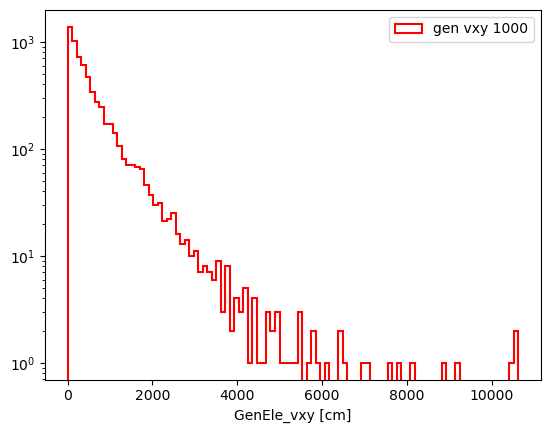

In [6]:
genelevxy1000 = tree1000["GenEle_vxy"].array()

plt.hist(genelevxy1000, bins=100,histtype="step",color = 'red', linewidth=1.5, label="gen vxy 1000")

plt.yscale("log")
plt.xlabel("GenEle_vxy [cm]")
plt.legend()
plt.show()

In [7]:
pdgs1000 = tree1000["GenPart_ID"].array()
mask1000 = pdgs1000==1000023


In [8]:
energy1000 = tree1000["GenPart_e"].array()
energychi21000=energy1000[mask1000]

mass1000 = tree1000["GenPart_mass"].array()
mchi21000 = mass1000[mask1000]

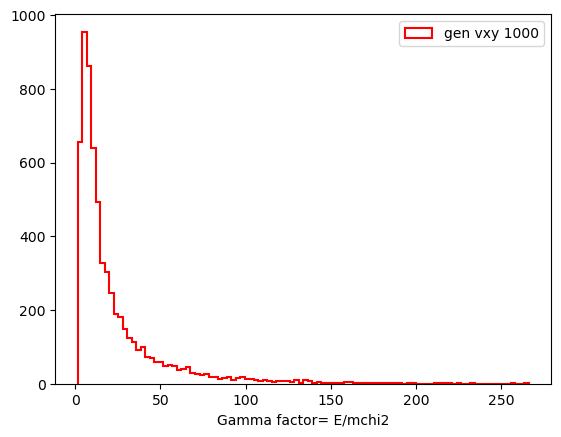

In [9]:
gamma1000= energychi21000/mchi21000

#plt.hist(gamma)
plt.hist(gamma1000, bins=100, histtype="step",color = 'red',linewidth=1.5, label="gen vxy 1000")
plt.xlabel("Gamma factor= E/mchi2")
plt.legend()
plt.show()

[1.882e+03 9.940e+02 6.940e+02 4.440e+02 3.710e+02 2.700e+02 2.480e+02
 2.050e+02 1.770e+02 1.510e+02 1.310e+02 1.270e+02 8.400e+01 8.200e+01
 4.700e+01 5.500e+01 3.800e+01 4.700e+01 3.800e+01 2.700e+01 3.800e+01
 2.400e+01 2.300e+01 2.100e+01 1.500e+01 1.600e+01 1.400e+01 1.000e+01
 1.400e+01 9.000e+00 6.000e+00 3.000e+00 9.000e+00 3.000e+00 1.000e+01
 4.000e+00 2.000e+00 3.000e+00 4.000e+00 1.000e+00 1.000e+00 5.000e+00
 0.000e+00 2.000e+00 1.000e+00 3.000e+00 2.000e+00 3.000e+00 0.000e+00
 1.000e+00 1.000e+00 1.000e+00 0.000e+00 0.000e+00 2.000e+00 1.000e+00
 1.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 1.000e+00 0.000e+00 0.000e+00 1.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 1.000e+00
 0.000e+00 0.000e+00 0.000e+00 1.000e+00 0.000e+00 0.000e+00 1.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
 0.000

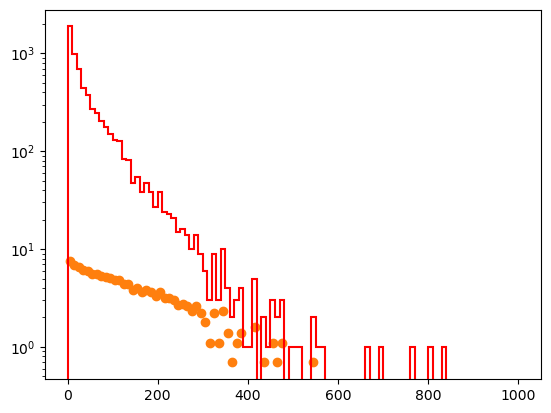

In [10]:
ctau1000= genelevxy1000/gamma1000

y,x, _=plt.hist(ctau1000, bins=100, histtype="step",linewidth=1.5, range=(0,1000),log=True, color = 'red', label="ctau0= 100cm sample")
print (y)

mask = y>0
y_fit = np.log(y[mask])

ct= (x[:-1] + x[1:])/2   #the ct values (in cm)
x_fit=ct[mask]

plt.scatter(x_fit, y_fit)

Text(0.5, 0, 'ctau(in cm)')

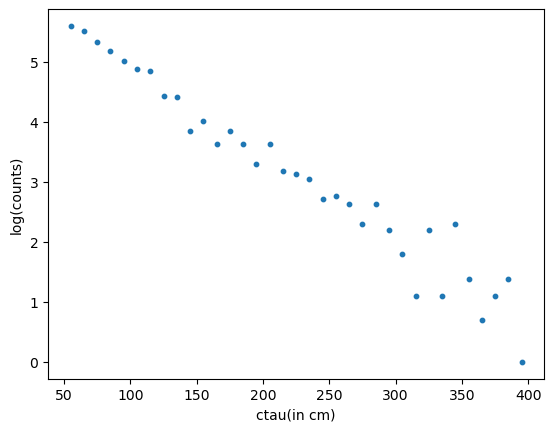

In [11]:
region = (x_fit>50) & (x_fit<400)
X_fit = x_fit[region]
Y_fit = y_fit[region]
plt.scatter(X_fit, Y_fit, s=10)
plt.ylabel("log(counts)")
plt.xlabel("ctau(in cm)")

In [12]:
def linear(X_fit,m,b):
    return (m*(X_fit)+b)

In [13]:
from scipy.optimize import curve_fit
#p0 = [-100,100]

params, cov = curve_fit(linear,X_fit,Y_fit)
m_fit, b_fit = params
ctau0 = -1/m_fit
print("Fitted m =", m_fit)  
print("ctau0 =", ctau0)  


Fitted m = -0.014261708798138928
ctau0 = 70.11782488017806


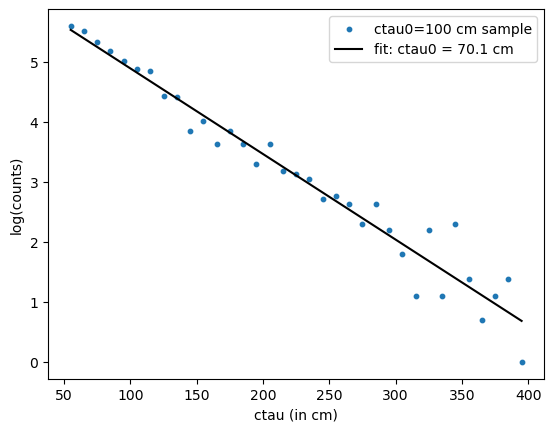

<Figure size 640x480 with 0 Axes>

In [14]:
plt.scatter(X_fit, Y_fit, s=10, label="ctau0=100 cm sample")
plt.plot(X_fit, linear(X_fit, m_fit, b_fit),color='black',label=f"fit: ctau0 = {ctau0:.1f} cm")

# plt.plot(x_fit, linear(x_fit, m, c), color="red",
#          label=f"fit: ctau0 = {ctau0:.1f}")
plt.xlabel("ctau (in cm)")
plt.ylabel("log(counts)")
plt.legend()
plt.show()

plt.savefig("ctauFIT.png", dpi=300)